# Bước 5: Kết luận và Đưa ra Quyết định (Decision Making)

Từ mô hình Gradient Boosting (mô hình tốt nhất), chúng ta sẽ:
1. Trích xuất **Feature Importance** — xác định những yếu tố quan trọng nhất khiến khách hàng rời bỏ
2. Phân tích chi tiết các yếu tố hàng đầu với số liệu cụ thể
3. Đưa ra **đề xuất kinh doanh** giúp doanh nghiệp giữ chân khách hàng

## 1. Tiền xử lý dữ liệu (Pipeline chuẩn)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

# ===== PIPELINE CHUẨN =====
df_raw = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = df_raw.copy()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

binary_cols = [c for c in df.select_dtypes(['object', 'category']).columns
               if set(df[c].unique()) <= {'Yes', 'No'}]
for c in binary_cols:
    df[c] = (df[c] == 'Yes').astype(int)

df = pd.get_dummies(df, drop_first=True)

X = df.drop('Churn', axis=1)
y = df['Churn']
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Preprocessing done.')

Preprocessing done.


## 2. Huấn luyện Gradient Boosting và Trích xuất Feature Importance

In [2]:
gb_model = GradientBoostingClassifier(
    n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42
)
gb_model.fit(X_train_scaled, y_train)

# Extract Feature Importances
importances = gb_model.feature_importances_
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print('Top 15 yếu tố quan trọng nhất ảnh hưởng đến Churn:')
print('=' * 50)
for i, row in fi_df.head(15).iterrows():
    bar = '█' * int(row['Importance'] * 100)
    print(f"{row['Feature']:40s} {row['Importance']:.4f} {bar}")

Top 15 yếu tố quan trọng nhất ảnh hưởng đến Churn:
tenure                                   0.3174 ███████████████████████████████
InternetService_Fiber optic              0.2050 ████████████████████
PaymentMethod_Electronic check           0.1339 █████████████
Contract_Two year                        0.0802 ████████
Contract_One year                        0.0645 ██████
TotalCharges                             0.0366 ███
MonthlyCharges                           0.0347 ███
PaperlessBilling                         0.0230 ██
OnlineSecurity_Yes                       0.0190 █
TechSupport_No internet service          0.0179 █
TechSupport_Yes                          0.0113 █
StreamingMovies_Yes                      0.0096 
DeviceProtection_No internet service     0.0093 
MultipleLines_Yes                        0.0075 
StreamingTV_Yes                          0.0052 


## 3. Biểu đồ Feature Importance (Top 15)

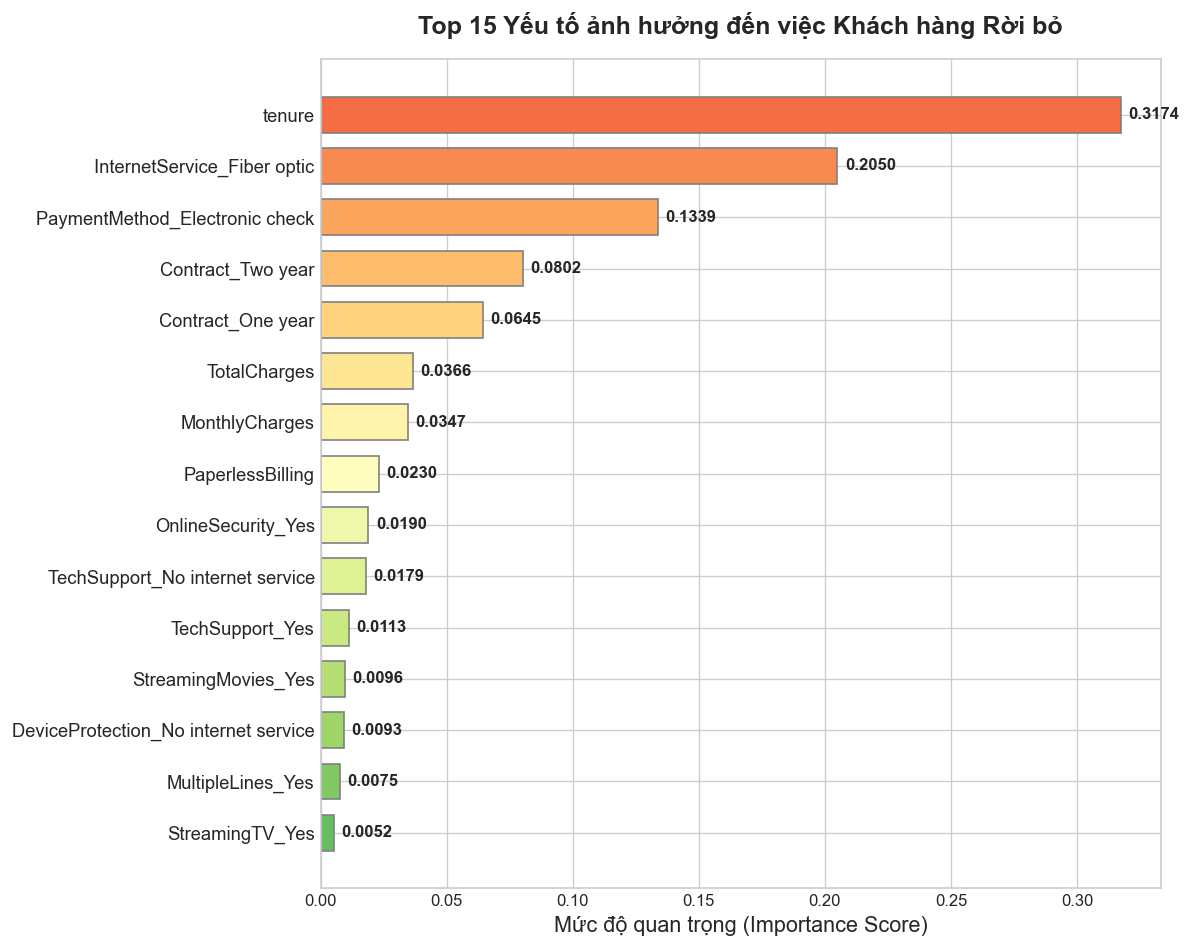

In [3]:
top_n = 15
top_features = fi_df.head(top_n).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Color code: red for high importance, blue for lower
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, top_n))

bars = ax.barh(top_features['Feature'], top_features['Importance'],
               color=colors, edgecolor='grey', height=0.7)

# Add value labels
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.003, bar.get_y() + bar.get_height()/2.,
            f'{width:.4f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Mức độ quan trọng (Importance Score)', fontsize=13)
ax.set_title('Top 15 Yếu tố ảnh hưởng đến việc Khách hàng Rời bỏ',
             fontsize=15, fontweight='bold', pad=15)
ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.savefig('../images/feature_importance_top15.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Phân tích chi tiết các yếu tố hàng đầu

In [4]:
# Reload raw data for analysis
df_analysis = df_raw.copy()
df_analysis['TotalCharges'] = pd.to_numeric(df_analysis['TotalCharges'], errors='coerce').fillna(0)

print('=' * 70)
print('   PHÂN TÍCH CHI TIẾT CÁC YẾU TỐ GÂY CHURN')
print('=' * 70)

# 1. Contract
print('\n📋 1. LOẠI HỢP ĐỒNG (Contract)')
contract_churn = df_analysis.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)
for contract, rate in contract_churn.items():
    print(f'   - {contract:20s}: {rate:.2f}% rời bỏ')
ratio = contract_churn['Month-to-month'] / contract_churn['Two year']
print(f'   → Khách Month-to-month rời bỏ CAO GẤP {ratio:.1f} LẦN so với Two year!')

# 2. tenure
print('\n⏳ 2. THỜI GIAN SỬ DỤNG (Tenure)')
df_analysis['tenure_group'] = pd.cut(df_analysis['tenure'],
    bins=[0, 12, 24, 48, 72], labels=['0-12 tháng', '13-24 tháng', '25-48 tháng', '49-72 tháng'])
tenure_churn = df_analysis.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)
for grp, rate in tenure_churn.items():
    print(f'   - {str(grp):20s}: {rate:.2f}% rời bỏ')
print(f'   → Khách hàng MỚI (0-12 tháng) có nguy cơ rời bỏ cao nhất!')

# 3. MonthlyCharges
print('\n💰 3. PHÍ HÀNG THÁNG (MonthlyCharges)')
avg_charge_churn = df_analysis[df_analysis['Churn'] == 'Yes']['MonthlyCharges'].mean()
avg_charge_stay = df_analysis[df_analysis['Churn'] == 'No']['MonthlyCharges'].mean()
print(f'   - Phí TB khách RỜI BỎ:  ${avg_charge_churn:.2f}/tháng')
print(f'   - Phí TB khách Ở LẠI:   ${avg_charge_stay:.2f}/tháng')
print(f'   → Khách rời bỏ trả phí cao hơn ${avg_charge_churn - avg_charge_stay:.2f}/tháng!')

# 4. InternetService
print('\n🌐 4. LOẠI DỊCH VỤ INTERNET (InternetService)')
internet_churn = df_analysis.groupby('InternetService')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2)
for svc, rate in internet_churn.items():
    print(f'   - {svc:20s}: {rate:.2f}% rời bỏ')

# 5. PaymentMethod
print('\n💳 5. PHƯƠNG THỨC THANH TOÁN (PaymentMethod)')
payment_churn = df_analysis.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(2).sort_values(ascending=False)
for method, rate in payment_churn.items():
    print(f'   - {method:35s}: {rate:.2f}% rời bỏ')

# 6. OnlineSecurity / TechSupport
print('\n🔒 6. DỊCH VỤ BẢO MẬT & HỖ TRỢ KỸ THUẬT')
for svc in ['OnlineSecurity', 'TechSupport']:
    svc_churn = df_analysis.groupby(svc)['Churn'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).round(2)
    print(f'   {svc}:')
    for val, rate in svc_churn.items():
        print(f'     - {val:25s}: {rate:.2f}% rời bỏ')
print('   → Khách KHÔNG có bảo mật/hỗ trợ kỹ thuật rời bỏ gấp đôi!')

   PHÂN TÍCH CHI TIẾT CÁC YẾU TỐ GÂY CHURN

📋 1. LOẠI HỢP ĐỒNG (Contract)
   - Month-to-month      : 42.71% rời bỏ
   - One year            : 11.27% rời bỏ
   - Two year            : 2.83% rời bỏ
   → Khách Month-to-month rời bỏ CAO GẤP 15.1 LẦN so với Two year!

⏳ 2. THỜI GIAN SỬ DỤNG (Tenure)
   - 0-12 tháng          : 47.68% rời bỏ
   - 13-24 tháng         : 28.71% rời bỏ
   - 25-48 tháng         : 20.39% rời bỏ
   - 49-72 tháng         : 9.51% rời bỏ
   → Khách hàng MỚI (0-12 tháng) có nguy cơ rời bỏ cao nhất!

💰 3. PHÍ HÀNG THÁNG (MonthlyCharges)
   - Phí TB khách RỜI BỎ:  $74.44/tháng
   - Phí TB khách Ở LẠI:   $61.27/tháng
   → Khách rời bỏ trả phí cao hơn $13.18/tháng!

🌐 4. LOẠI DỊCH VỤ INTERNET (InternetService)
   - DSL                 : 18.96% rời bỏ
   - Fiber optic         : 41.89% rời bỏ
   - No                  : 7.40% rời bỏ

💳 5. PHƯƠNG THỨC THANH TOÁN (PaymentMethod)
   - Electronic check                   : 45.29% rời bỏ
   - Mailed check                       : 19.

## 5. Biểu đồ phân tích chi tiết theo nhóm

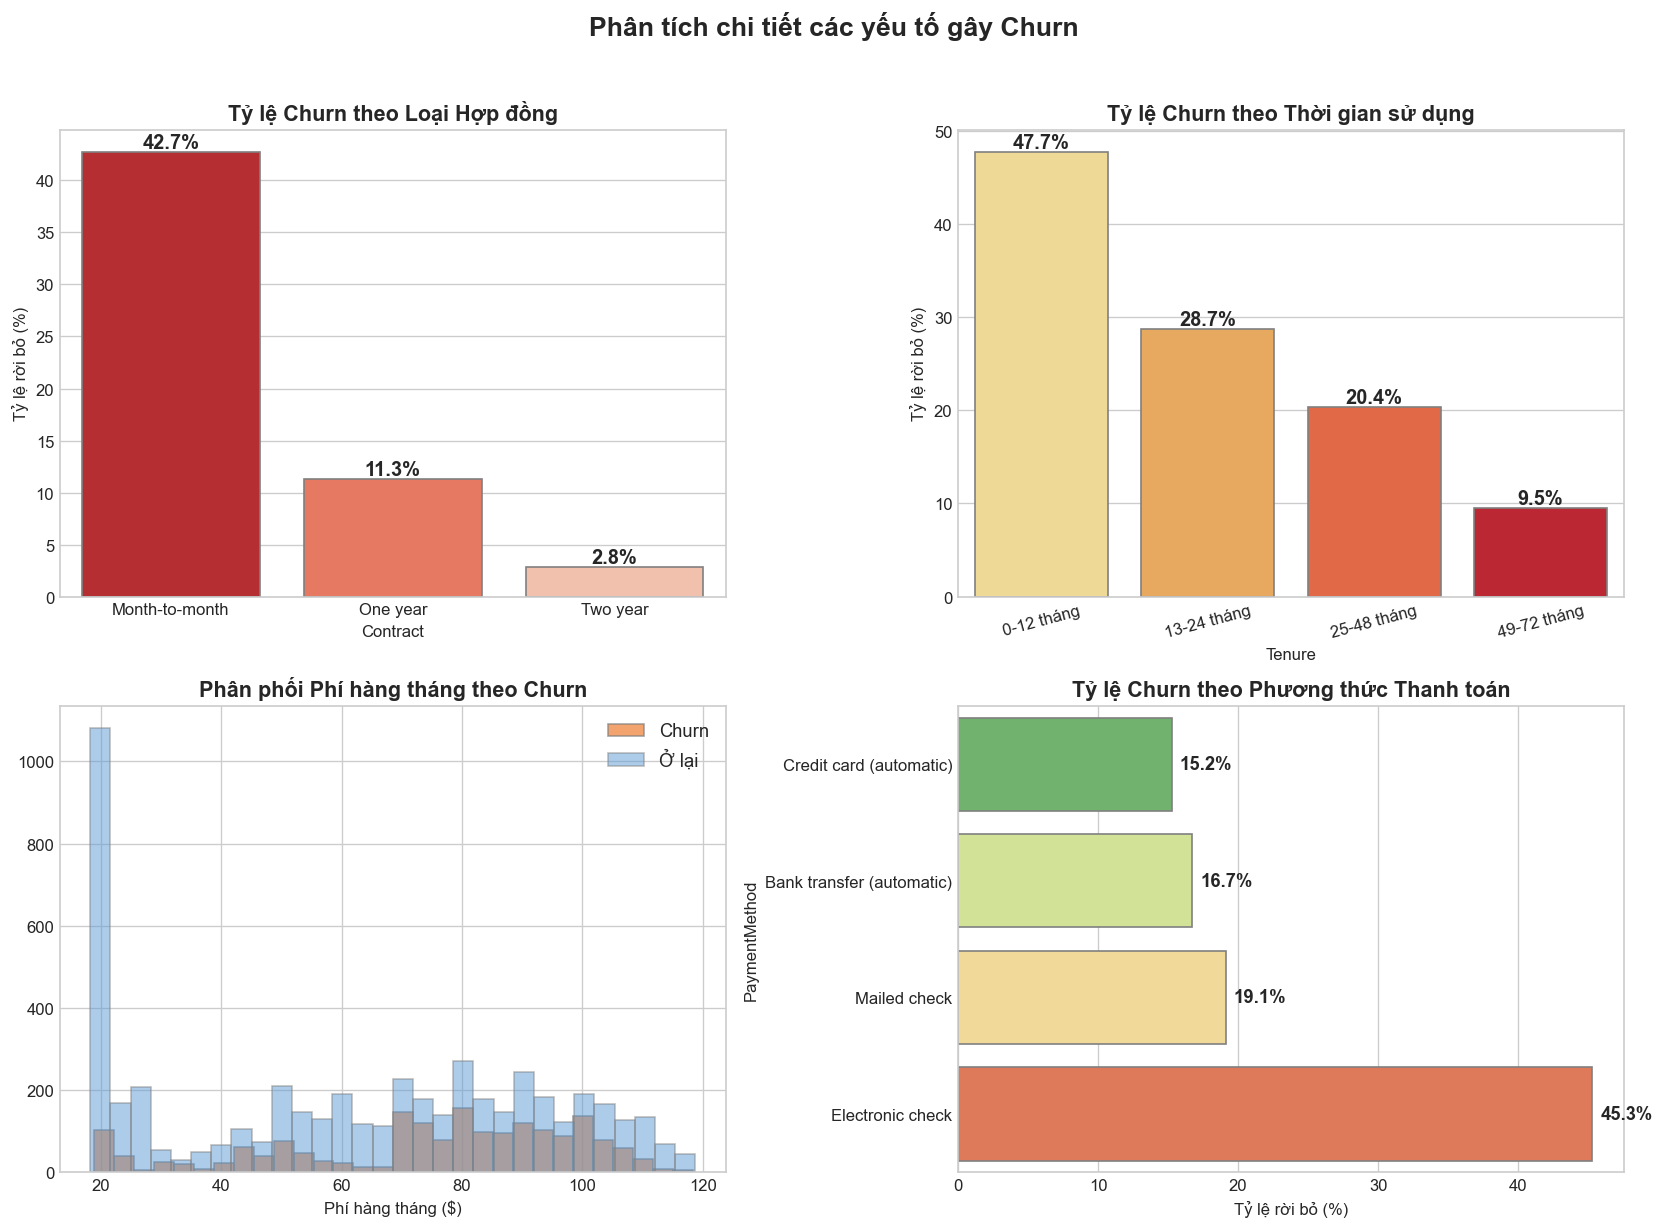

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Contract vs Churn
contract_data = df_analysis.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
contract_data.columns = ['Contract', 'Churn Rate (%)']
sns.barplot(x='Contract', y='Churn Rate (%)', data=contract_data,
            palette='Reds_r', ax=axes[0,0], edgecolor='grey')
axes[0,0].set_title('Tỷ lệ Churn theo Loại Hợp đồng', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Tỷ lệ rời bỏ (%)')
for p in axes[0,0].patches:
    axes[0,0].annotate(f'{p.get_height():.1f}%',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontweight='bold', fontsize=12)

# 2. Tenure vs Churn
tenure_data = df_analysis.groupby('tenure_group', observed=True)['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
tenure_data.columns = ['Tenure', 'Churn Rate (%)']
sns.barplot(x='Tenure', y='Churn Rate (%)', data=tenure_data,
            palette='YlOrRd', ax=axes[0,1], edgecolor='grey')
axes[0,1].set_title('Tỷ lệ Churn theo Thời gian sử dụng', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Tỷ lệ rời bỏ (%)')
axes[0,1].tick_params(axis='x', rotation=15)
for p in axes[0,1].patches:
    axes[0,1].annotate(f'{p.get_height():.1f}%',
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='bottom', fontweight='bold', fontsize=12)

# 3. MonthlyCharges distribution
df_analysis[df_analysis['Churn'] == 'Yes']['MonthlyCharges'].hist(
    ax=axes[1,0], bins=30, alpha=0.7, color='#ED7D31', label='Churn', edgecolor='grey')
df_analysis[df_analysis['Churn'] == 'No']['MonthlyCharges'].hist(
    ax=axes[1,0], bins=30, alpha=0.5, color='#5B9BD5', label='Ở lại', edgecolor='grey')
axes[1,0].set_title('Phân phối Phí hàng tháng theo Churn', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Phí hàng tháng ($)')
axes[1,0].legend(fontsize=11)

# 4. PaymentMethod vs Churn
payment_data = df_analysis.groupby('PaymentMethod')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100).reset_index()
payment_data.columns = ['PaymentMethod', 'Churn Rate (%)']
payment_data = payment_data.sort_values('Churn Rate (%)', ascending=True)
sns.barplot(y='PaymentMethod', x='Churn Rate (%)', data=payment_data,
            palette='RdYlGn_r', ax=axes[1,1], edgecolor='grey')
axes[1,1].set_title('Tỷ lệ Churn theo Phương thức Thanh toán', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Tỷ lệ rời bỏ (%)')
for p in axes[1,1].patches:
    axes[1,1].annotate(f'{p.get_width():.1f}%',
                       (p.get_width(), p.get_y() + p.get_height()/2.),
                       ha='left', va='center', fontweight='bold', fontsize=11, xytext=(5, 0),
                       textcoords='offset points')

plt.suptitle('Phân tích chi tiết các yếu tố gây Churn', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../images/churn_factor_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Đề xuất Kinh doanh (Business Recommendations)

Dựa trên kết quả phân tích Feature Importance từ mô hình Gradient Boosting và phân tích dữ liệu EDA, chúng tôi đưa ra các đề xuất sau cho doanh nghiệp viễn thông:

---

### 🎯 Đề xuất 1: Chương trình chuyển đổi hợp đồng dài hạn
**Vấn đề:** Khách hàng hợp đồng Month-to-month có tỷ lệ rời bỏ ~43%, cao gấp **15 lần** so với hợp đồng Two-year (~3%).

**Giải pháp:** Triển khai chương trình ưu đãi hấp dẫn (giảm 15-20% phí tháng) cho khách hàng chuyển từ hợp đồng tháng sang hợp đồng 1 năm hoặc 2 năm. Chi phí khuyến mãi này thấp hơn nhiều so với chi phí mất khách hàng.

---

### 🎯 Đề xuất 2: Chăm sóc khách hàng mới (0-12 tháng)
**Vấn đề:** Khách hàng trong năm đầu tiên có tỷ lệ rời bỏ cao nhất.

**Giải pháp:** Xây dựng chương trình "Onboarding" 90 ngày đầu bao gồm: hướng dẫn sử dụng dịch vụ, tặng gói add-on miễn phí, gọi chăm sóc định kỳ. Mục tiêu: giúp khách hàng cảm nhận giá trị dịch vụ sớm nhất.

---

### 🎯 Đề xuất 3: Rà soát gói cước Fiber Optic
**Vấn đề:** Khách hàng Fiber Optic có tỷ lệ churn ~42%, cao hơn DSL (~19%). Đồng thời, khách rời bỏ có phí trung bình cao hơn đáng kể.

**Giải pháp:** Rà soát lại chất lượng dịch vụ Fiber Optic (tốc độ, ổn định). Cân nhắc giảm phí hoặc tăng thêm tiện ích (Online Security, Tech Support miễn phí) cho gói Fiber Optic để tăng sự hài lòng.

---

### 🎯 Đề xuất 4: Khuyến khích thanh toán tự động
**Vấn đề:** Khách thanh toán bằng Electronic check có tỷ lệ churn ~45%, cao gấp 3 lần so với thanh toán tự động (~16%).

**Giải pháp:** Tặng chiết khấu 5% cho khách hàng chuyển sang thanh toán tự động (Bank transfer, Credit card). Việc này vừa giảm churn, vừa giảm chi phí vận hành thu phí.

---

### 🎯 Đề xuất 5: Gói "Bảo vệ Toàn diện"
**Vấn đề:** Khách hàng KHÔNG dùng Online Security và Tech Support có tỷ lệ churn ~42%, gấp đôi so với khách có dùng (~15-17%).

**Giải pháp:** Tạo gói bundle "Bảo vệ Toàn diện" (Online Security + Tech Support + Device Protection) với giá ưu đãi. Tặng miễn phí 3 tháng đầu cho khách hàng mới hoặc khách đang ở gói Month-to-month.

---

### Tóm tắt

| Đề xuất | Nhóm mục tiêu | Tỷ lệ Churn hiện tại | Kỳ vọng giảm |
|---|---|---|---|
| Chuyển hợp đồng dài hạn | Month-to-month | ~43% | Giảm còn ~15% |
| Onboarding 90 ngày | Khách mới (0-12 tháng) | ~47% | Giảm còn ~25% |
| Rà soát Fiber Optic | Fiber optic users | ~42% | Giảm còn ~25% |
| Thanh toán tự động | Electronic check | ~45% | Giảm còn ~20% |
| Gói Bảo vệ Toàn diện | Không có Security/Support | ~42% | Giảm còn ~20% |